# Peramalan Kadar NO₂ di Daerah Samarinda, Kalimantan Timur

Notebook ini berisi keseluruhan pipeline untuk meramalkan kadar **Nitrogen Dioksida (NO₂)** di daerah Samarinda, Kalimantan Timur, menggunakan data satelit Sentinel-5P dari Copernicus dan model **KNN Regression**.

### Alur kerja:
1. Pengumpulan data dari Copernicus Dataspace (openEO)
2. Preprocessing: handling missing value, outlier, dan normalisasi
3. Modeling dengan KNN Regression & evaluasi performa

---

## 1. 📡 Pengumpulan Data

Data yang kita pakai adalah **Time Series Harian kadar NO₂** di wilayah Samarinda, Kalimantan Timur, yang diambil dari satelit Sentinel-5P milik ESA lewat platform [Copernicus Dataspace](https://dataspace.copernicus.eu/).

### Langkah-langkah pengambilan data:
1. Buat akun di [https://dataspace.copernicus.eu/](https://dataspace.copernicus.eu/)
2. Buka JupyterLab di [https://dataspace.copernicus.eu/analyse/jupyterlab](https://dataspace.copernicus.eu/analyse/jupyterlab)
3. Pilih kernel **Python 3 (ipykernel)**
4. Install library `openeo` dan jalankan script pengambilan data

### Koordinat Area Samarinda
Untuk menentukan area yang ingin diambil datanya, kita pakai website [geojson.io](https://geojson.io) lalu gambar kotak di atas peta Samarinda.

> ⚠️ **Catatan**: Koordinat di bawah ini adalah estimasi untuk wilayah Samarinda. Disarankan untuk cek ulang dan sesuaikan lewat [geojson.io](https://geojson.io) agar lebih akurat.

| Batas | Nilai |
|-------|-------|
| West  | 116.75 |
| East  | 117.25 |
| South | -0.85 |
| North | -0.35 |

---

In [1]:
# Install library openeo terlebih dahulu
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import openeo

# Konek ke server Copernicus dan autentikasi
# Nanti akan muncul link, klik link tersebut dan login pakai akun Copernicus kamu
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=LRIU-LAVZ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### Definisi Area of Interest (AOI) dan Load Collection

Setelah terkoneksi, kita definisikan area Samarinda sebagai polygon GeoJSON, lalu load data NO₂ dari koleksi **SENTINEL_5P_L2** untuk rentang waktu Oktober 2023 – September 2025.

Data diproses dua kali:
- **Agregasi harian** (`aggregate_temporal_period`): agar satu hari hanya punya satu nilai rata-rata
- **Agregasi spasial** (`aggregate_spatial`): agar seluruh grid di dalam area Samarinda dirata-rata jadi satu nilai

In [3]:

aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [117.25, -0.35],
            [116.75, -0.35],
            [116.75, -0.85],
            [117.25, -0.85],
            [117.25, -0.35],
        ]
    ]
}


s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 116.75,
        "south": -0.85,
        "east": 117.25,
        "north": -0.35
    },
    bands=["NO2"],
)

# Rata-rata per hari (agar tidak ada duplikat data dalam satu hari)
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Rata-rata spasial (semua grid dalam area Samarinda dijadikan satu nilai)
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [4]:
# Mulai proses pengambilan data (batch job)
job = s5post.execute_batch(title="NO2 in Samarinda", outputfile="NO2Samarinda.nc")

# Setelah selesai, unduh file .nc dari:
# https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2
# Cari nama job 'NO2 in Samarinda' dengan status 'finished', lalu klik tombol download

0:00:00 Job 'j-26060304150449d4b5fa767d81ddca81': send 'start'
0:00:14 Job 'j-26060304150449d4b5fa767d81ddca81': queued (progress 0%)
0:00:19 Job 'j-26060304150449d4b5fa767d81ddca81': queued (progress 0%)
0:00:26 Job 'j-26060304150449d4b5fa767d81ddca81': queued (progress 0%)
0:00:34 Job 'j-26060304150449d4b5fa767d81ddca81': queued (progress 0%)
0:00:44 Job 'j-26060304150449d4b5fa767d81ddca81': queued (progress 0%)
0:00:56 Job 'j-26060304150449d4b5fa767d81ddca81': queued (progress 0%)
0:01:12 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)
0:01:31 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)
0:01:55 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)
0:02:25 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)
0:03:03 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)
0:03:50 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)
0:04:48 Job 'j-26060304150449d4b5fa767d81ddca81': running (progress N/A)


---
## 2. 🛠️ Preprocessing Data

Setelah file `.nc` berhasil diunduh, kita lakukan serangkaian preprocessing:

| Langkah | Tujuan |
|---------|--------|
| a. Baca file NetCDF | Ekstrak kolom date & NO₂ |
| b. Interpolasi missing value (grid) | Isi nilai `--` pada data raw |
| c. Rata-rata & ubah format datetime | 1 hari = 1 nilai NO₂ |
| d. Simpan ke CSV | Format yang lebih mudah diolah |
| e. Cek & isi missing date harian | Pastikan tidak ada tanggal yang bolong |
| f. Deteksi & hapus outlier (IQR) | Hilangkan nilai ekstrem yang tidak wajar |

---

### 2a. Baca File NetCDF dan Lihat Struktur Data

Data yang diunduh berbentuk `.nc` (NetCDF). Kita perlu ekstrak dua variabel:
- `t` → waktu
- `NO2` → kadar NO₂

Struktur data NO₂ adalah 3D array: `[waktu, baris_grid, kolom_grid]`

In [6]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.2 MB/s eta 0:00:00


In [9]:
import netCDF4
import numpy as np
import pandas as pd

file_path = "NO2Samarinda.nc"
ds = netCDF4.Dataset(file_path)

# Lihat semua variabel yang tersedia dalam file
print("📦 Variabel dalam file:")
print(ds.variables.keys())

# Ambil data NO2 dan waktu
no2 = ds.variables["NO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

# Cek struktur data NO2
print("\n📐 Struktur data NO2:")
print(f"Tipe data        : {type(no2)}")
print(f"Jumlah record    : {len(no2)}")
print(f"Jumlah baris grid: {len(no2[0])}")
print(f"Jumlah kolom grid: {len(no2[0][0])}")
print(f"Contoh nilai     : {no2[0][0][0]}")

# Lihat 10 data pertama
print("\n📋 Contoh 10 data pertama:")
for i in range(0, 10):
    print(no2[i])

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

📐 Struktur data NO2:
Tipe data        : <class 'numpy.ma.MaskedArray'>
Jumlah record    : 728
Jumlah baris grid: 15
Jumlah kolom grid: 10
Contoh nilai     : --

📋 Contoh 10 data pertama:
[[-- -- -- 3.6768453810509527e-06 -- 1.539434742880985e-05
  1.8005966921919025e-05 -- -- --]
 [-- -- 9.040981012731208e-07 -- 1.225763753609499e-05
  1.539434742880985e-05 1.8005966921919025e-05 -- -- --]
 [-- -- -- -- 2.1282636225805618e-05 1.795878961274866e-05
  1.4627353266405407e-05 -- -- --]
 [-- -- -- 2.8046415536664426e-06 1.9518840417731553e-05
  2.0573383153532632e-05 -- -- -- --]
 [-- -- 3.3480364436400123e-06 7.895683665992692e-06 --
  2.0573383153532632e-05 -- -- -- --]
 [-- -- 3.3480364436400123e-06 3.113303682766855e-05
  1.382312439091038e-05 1.7406238839612342e-05 1.388206692354288e-05 --
  -- --]
 [-- -- 2.2732261641067453e-05 -- 1.382312439091038e-05 -- -- -- -- --]
 [-- -- -- -- 1.9235034415032715e-05 -- -- -- -- 2.04

### 2b. Interpolasi Missing Value pada Grid

Pada data raw, banyak nilai `--` (masked) yang artinya satelit tidak berhasil merekam nilai NO₂ di titik tersebut — bisa karena awan atau gangguan sinyal.

Solusinya: **Interpolasi Linear** per titik grid. Nilai yang hilang diisi berdasarkan nilai sebelum dan sesudahnya secara linier.

In [10]:
# Interpolasi Linear untuk setiap titik grid
no2_filled = np.zeros_like(no2)
no2_filled = no2_filled.filled(0)

for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

print("✅ Interpolasi grid selesai!")

✅ Interpolasi grid selesai!


### 2c. Rata-rata dan Format Ulang Datetime

Semua piksel grid dirata-rata jadi **satu nilai NO₂ per hari**. Format datetime juga disederhanakan dari `2023-10-04 00:00:00` menjadi `2023-10-04`.

In [11]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

print(f"✅ Total record: {len(new_dates)} hari")
print(f"Contoh: {new_dates[0]} → NO2 = {new_no2[0]:.6e}")

✅ Total record: 728 hari
Contoh: 2023-10-01 → NO2 = 1.549890e-05


### 2d. Simpan ke CSV

In [12]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv("NO2_Samarinda_timeseries.csv", index=False)
print("✅ Data berhasil disimpan ke NO2_Samarinda_timeseries.csv")
print(df.head())

✅ Data berhasil disimpan ke NO2_Samarinda_timeseries.csv
         date       NO2
0  2023-10-01  0.000015
1  2023-10-02  0.000015
2  2023-10-03  0.000016
3  2023-10-04  0.000015
4  2023-10-05  0.000016


### 2e. Pengecekan Missing Date pada Data Harian

Kita cek kelengkapan tanggal dari 1 Oktober 2023 – 30 September 2025. Kalau ada tanggal yang bolong, kita isi pakai interpolasi linear.

In [13]:
df = pd.read_csv("NO2_Samarinda_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 3
Daftar tanggal missing:
DatetimeIndex(['2024-01-01', '2024-03-23', '2024-08-12'], dtype='datetime64[ns]', freq=None)


In [14]:
# Isi tanggal yang hilang dengan interpolasi
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

df['NO2'] = df['NO2'].interpolate(method='time')
df['NO2'] = df['NO2'].bfill().ffill()

df.to_csv("no2_samarinda_interpolated.csv")

# Verifikasi
df_check = df.reset_index()
missing_after = full_range.difference(df_check['date'])
print(f"Jumlah hari missing setelah interpolasi: {len(missing_after)}")
print("✅ Semua tanggal sudah lengkap!")

Jumlah hari missing setelah interpolasi: 0
✅ Semua tanggal sudah lengkap!


In [15]:
df = pd.read_csv("no2_samarinda_interpolated.csv")
df['date'] = pd.to_datetime(df['date'])

print(df.head())
print()
print(df.info())

        date       NO2
0 2023-10-01  0.000015
1 2023-10-02  0.000015
2 2023-10-03  0.000016
3 2023-10-04  0.000015
4 2023-10-05  0.000016

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    731 non-null    datetime64[ns]
 1   NO2     731 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.6 KB
None


### 2f. Deteksi Outlier menggunakan Metode IQR

Outlier dideteksi pakai metode **IQR (Interquartile Range)**:
- **Lower Bound** = Q1 − 1.5 × IQR  
- **Upper Bound** = Q3 + 1.5 × IQR

Data di luar range ini dianggap outlier, lalu diganti dengan nilai interpolasi linear.

In [16]:
import matplotlib.pyplot as plt

df = pd.read_csv("no2_samarinda_interpolated.csv")
df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.6e} | Q3: {Q3:.6e} | IQR: {IQR:.6e}")
print(f"Lower Bound: {lower_bound:.6e}")
print(f"Upper Bound: {upper_bound:.6e}")

outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]
print(f"\nJumlah Outlier (IQR): {len(outliers_iqr)}")
print(outliers_iqr[['date', 'NO2']].head())

Q1: 9.767003e-06 | Q3: 1.347797e-05 | IQR: 3.710964e-06
Lower Bound: 4.200557e-06
Upper Bound: 1.904441e-05

Jumlah Outlier (IQR): 11
         date       NO2
26 2023-10-27  0.000020
27 2023-10-28  0.000022
28 2023-10-29  0.000020
29 2023-10-30  0.000019
43 2023-11-13  0.000020


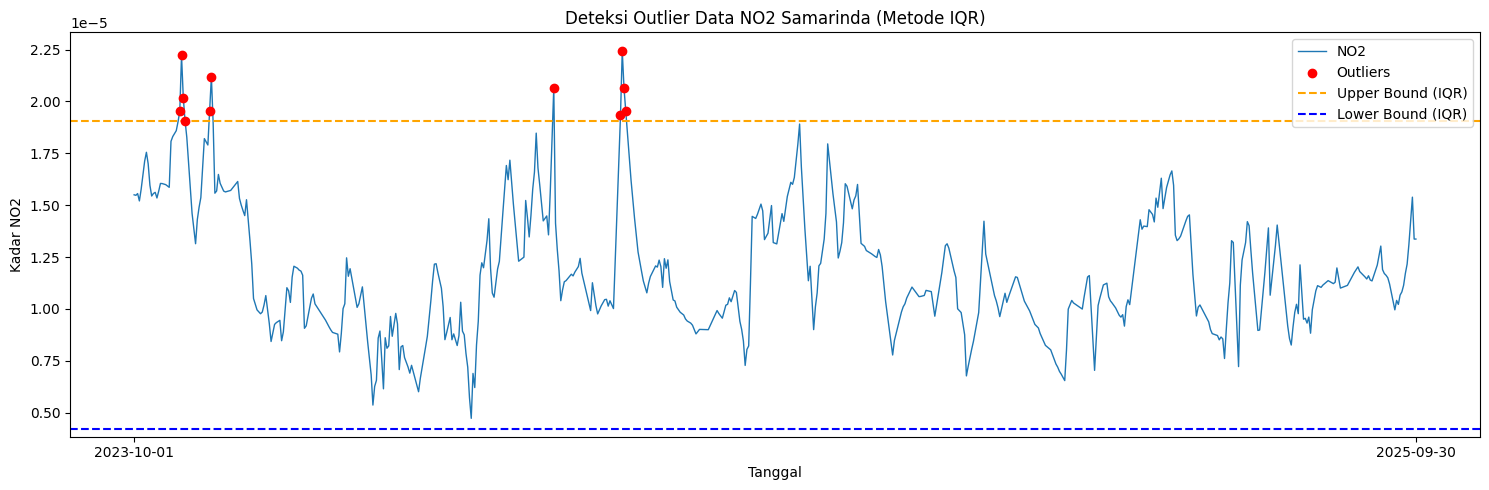

In [17]:
# Visualisasi outlier pada time series
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers", zorder=5)
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data NO2 Samarinda (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.tight_layout()
plt.show()

In [18]:
# Hapus outlier lalu isi ulang pakai interpolasi linear
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))
print(f"Jumlah nilai yang ditandai sebagai outlier: {df['NO2_cleaned'].isna().sum()}")

df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

print(f"Jumlah missing setelah interpolasi: {df['NO2_filled'].isna().sum()}")
print("✅ Outlier berhasil dihapus dan diisi ulang!")

Jumlah nilai yang ditandai sebagai outlier: 11
Jumlah missing setelah interpolasi: 0
✅ Outlier berhasil dihapus dan diisi ulang!


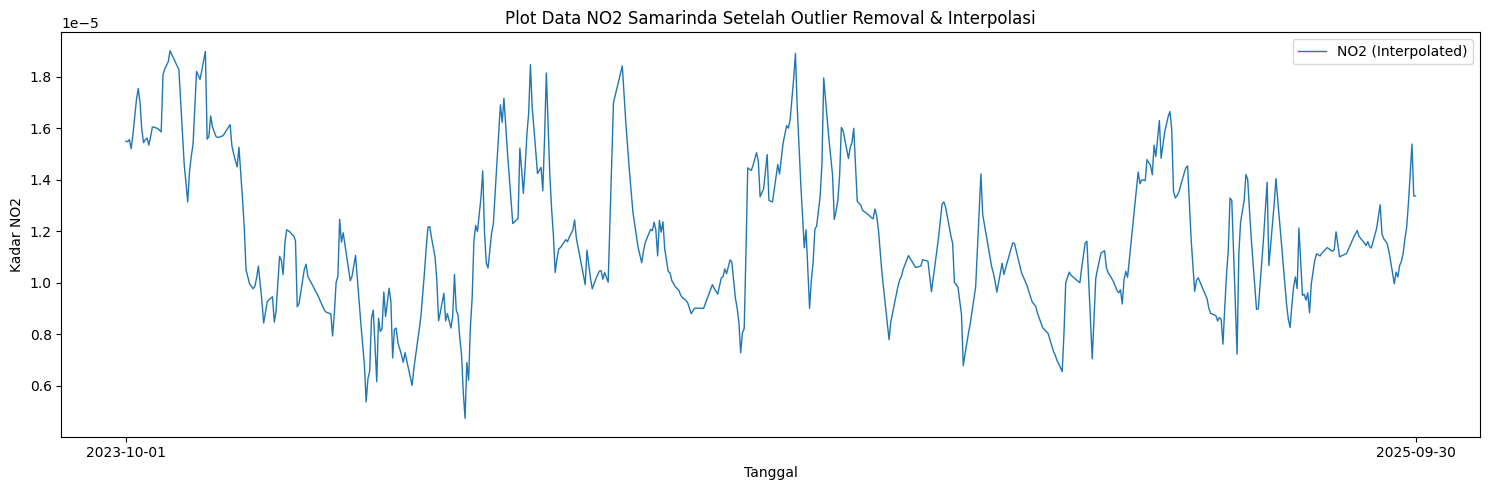

In [19]:
# Visualisasi data setelah outlier dihapus
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Samarinda Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. 🤖 Modeling menggunakan KNN Regression

Tujuan: **memprediksi kadar NO₂ hari ini (t) berdasarkan kadar NO₂ beberapa hari sebelumnya**.

Langkah-langkah:
1. Normalisasi data (Min-Max Scaler)
2. Uji korelasi antar lag untuk memilih fitur terbaik
3. Buat dataset supervised (4, 10, 30 lag)
4. Train & evaluasi model KNN
5. Visualisasi hasil prediksi

---

### 3a. Normalisasi Data (Min-Max Scaler)

KNN bekerja berbasis jarak antar data poin, jadi semua nilai NO₂ perlu dinormalisasi ke rentang **0–1** supaya skalanya seragam.

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

print(df[['date', 'NO2_filled', 'NO2_scaled']].head())
print(f"\nMin: {df['NO2_scaled'].min():.4f} | Max: {df['NO2_scaled'].max():.4f}")

        date  NO2_filled  NO2_scaled
0 2023-10-01    0.000015    0.754057
1 2023-10-02    0.000015    0.752285
2 2023-10-03    0.000016    0.758165
3 2023-10-04    0.000015    0.733378
4 2023-10-05    0.000016    0.772407

Min: 0.0000 | Max: 1.0000


### 3b. Uji Korelasi Lag

Kita cek seberapa kuat hubungan antara hari-hari sebelumnya dengan hari ini (t). Lag dengan korelasi **> 0.5** dianggap signifikan dan akan dipakai sebagai fitur.

In [21]:
def create_supervised(data, n_lag=4):
    """Ubah time series jadi format supervised learning dengan lag features."""
    df_supervised = pd.DataFrame()
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    df_supervised['NO2(t)'] = data
    df_supervised.dropna(inplace=True)
    return df_supervised

# Buat data supervised dengan 30 lag untuk uji korelasi
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

print("Nilai korelasi tiap lag terhadap NO2(t):")
print(correlations)
print("\n🔍 Lag dengan korelasi > 0.5 (signifikan):")
print(correlations[correlations > 0.5])

Nilai korelasi tiap lag terhadap NO2(t):
NO2(t-30)    0.171892
NO2(t-29)    0.192366
NO2(t-28)    0.215734
NO2(t-27)    0.236188
NO2(t-26)    0.250494
NO2(t-25)    0.258887
NO2(t-24)    0.268073
NO2(t-23)    0.280234
NO2(t-22)    0.294970
NO2(t-21)    0.314628
NO2(t-20)    0.338033
NO2(t-19)    0.364276
NO2(t-18)    0.386555
NO2(t-17)    0.405110
NO2(t-16)    0.421701
NO2(t-15)    0.429880
NO2(t-14)    0.433932
NO2(t-13)    0.438638
NO2(t-12)    0.449456
NO2(t-11)    0.464555
NO2(t-10)    0.480510
NO2(t-9)     0.501028
NO2(t-8)     0.522236
NO2(t-7)     0.557293
NO2(t-6)     0.603078
NO2(t-5)     0.660637
NO2(t-4)     0.725999
NO2(t-3)     0.801210
NO2(t-2)     0.878593
NO2(t-1)     0.951496
dtype: float64

🔍 Lag dengan korelasi > 0.5 (signifikan):
NO2(t-9)    0.501028
NO2(t-8)    0.522236
NO2(t-7)    0.557293
NO2(t-6)    0.603078
NO2(t-5)    0.660637
NO2(t-4)    0.725999
NO2(t-3)    0.801210
NO2(t-2)    0.878593
NO2(t-1)    0.951496
dtype: float64


### 3c. Buat Dataset Supervised (4, 10, dan 30 Lag)

Kita buat tiga versi dataset untuk dibandingkan apakah semakin banyak lag = semakin baik modelnya.

In [22]:
# Dataset 4 hari sebelumnya
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)
print("Dataset 4 lag:")
print(supervised_df)
print("Shape:", supervised_df.shape)

# Dataset 10 hari sebelumnya
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)
print("\nDataset 10 lag shape:", supervised_df10.shape)

# Dataset 30 hari sebelumnya
print("Dataset 30 lag shape:", supervised_df30.shape)

Dataset 4 lag:
     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.754057  0.752285  0.758165  0.733378  0.772407
5    0.752285  0.758165  0.733378  0.772407  0.820730
6    0.758165  0.733378  0.772407  0.820730  0.867437
7    0.733378  0.772407  0.820730  0.867437  0.897427
8    0.772407  0.820730  0.867437  0.897427  0.858786
..        ...       ...       ...       ...       ...
726  0.426508  0.448798  0.488969  0.520266  0.586161
727  0.448798  0.488969  0.520266  0.586161  0.666121
728  0.488969  0.520266  0.586161  0.666121  0.746081
729  0.520266  0.586161  0.666121  0.746081  0.604746
730  0.586161  0.666121  0.746081  0.604746  0.604746

[727 rows x 5 columns]
Shape: (727, 5)

Dataset 10 lag shape: (721, 11)
Dataset 30 lag shape: (701, 31)


### 3d. Training dan Evaluasi Model KNN

Setting model:
- **Algoritma**: KNN Regression (K=5)
- **Split data**: 80% train, 20% test (tidak di-shuffle karena time series)
- **Metrik evaluasi**: RMSE, R², MAPE

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split 80/20, tidak di-shuffle (penting untuk time series!)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size : {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE       : {rmse:.6f}")
    print(f"R²         : {r2:.4f}")
    print(f"MAPE       : {mape:.4f}%")

    return knn, y_test, y_pred

# Train ketiga model
knn_4,  y_test_4,  y_pred_4  = train_knn(supervised_df,   "KNN - 4 Hari Sebelumnya")
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size : 581 — Test Size: 146
RMSE       : 0.067624
R²         : 0.7434
MAPE       : 10.9095%

=== KNN - 10 Hari Sebelumnya ===
Train Size : 576 — Test Size: 145
RMSE       : 0.083273
R²         : 0.5958
MAPE       : 14.2384%

=== KNN - 30 Hari Sebelumnya ===
Train Size : 560 — Test Size: 141
RMSE       : 0.103893
R²         : 0.2899
MAPE       : 18.2323%


### Analisis Hasil Evaluasi

Bandingkan performa ketiga model dari output di atas. Hal yang perlu diperhatikan:
- Apakah model 4 lag masih yang terbaik seperti pada data Bangkalan?
- Apakah menambah lag justru menurunkan performa (curse of dimensionality)?
- MAPE berapa persen? Di bawah 20% dianggap baik, di atas 50% masih rendah.

> 💡 Kalau MAPE masih tinggi, bisa dicoba model lain seperti **LSTM**, **ARIMA**, atau tambah fitur meteorologi (suhu, angin, hujan).

### 3e. Visualisasi: Aktual vs Prediksi

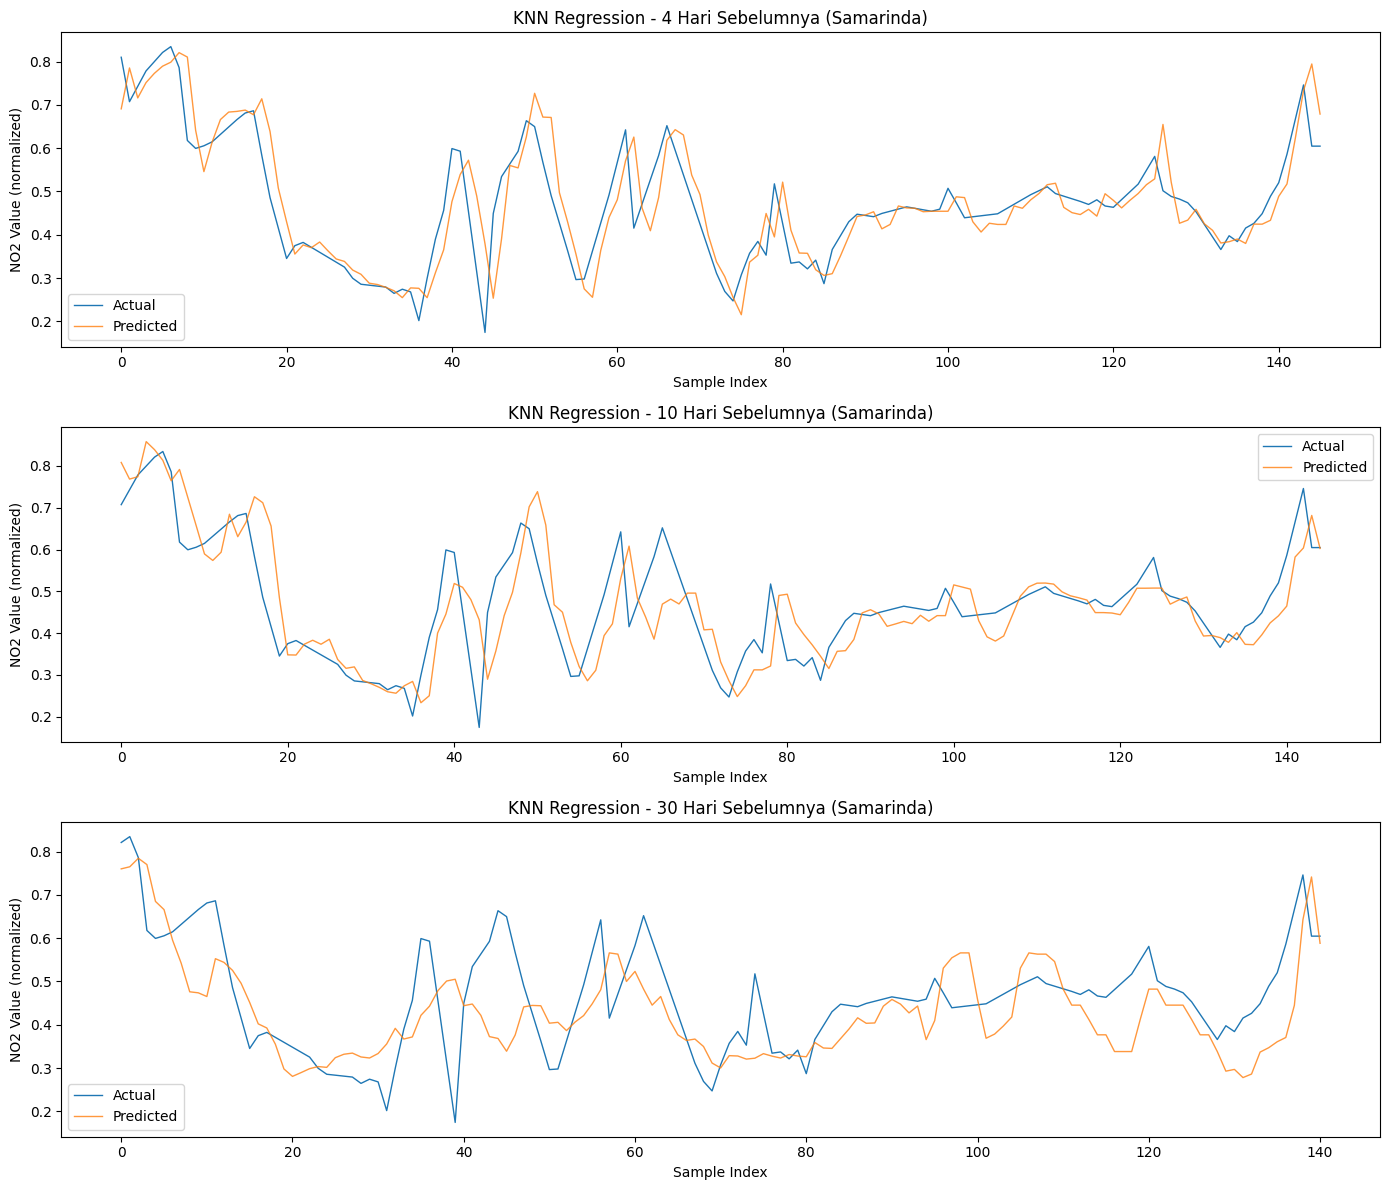

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

configs = [
    (y_test_4,  y_pred_4,  "KNN Regression - 4 Hari Sebelumnya (Samarinda)"),
    (y_test_10, y_pred_10, "KNN Regression - 10 Hari Sebelumnya (Samarinda)"),
    (y_test_30, y_pred_30, "KNN Regression - 30 Hari Sebelumnya (Samarinda)"),
]

for ax, (y_test, y_pred, title) in zip(axes, configs):
    ax.plot(np.arange(len(y_test)), y_test, label="Actual", linewidth=1)
    ax.plot(np.arange(len(y_pred)), y_pred, label="Predicted", linewidth=1, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("NO2 Value (normalized)")
    ax.legend()

plt.tight_layout()
plt.show()

---
## 📋 Kesimpulan

1. **Data NO₂ Samarinda** diambil dari satelit Sentinel-5P Copernicus untuk periode Oktober 2023 – September 2025

2. **Preprocessing** yang dilakukan:
   - Interpolasi linear untuk missing value pada level grid
   - Rata-rata spasial semua piksel → 1 nilai harian
   - Pengisian tanggal yang hilang via interpolasi temporal
   - Penghapusan dan pengisian ulang outlier via IQR + interpolasi

3. **Model KNN Regression** diuji dengan 3 konfigurasi lag (4, 10, 30 hari)

4. **Rekomendasi** untuk penelitian selanjutnya:
   - Coba model **LSTM** atau **GRU** untuk time series yang lebih kompleks
   - Tambahkan fitur meteorologi (suhu, angin, curah hujan)
   - Coba **ARIMA/SARIMA** sebagai baseline statistik
   - Eksplorasi nilai K yang berbeda pada KNN

---
